In [1]:
####### import libraraies #############################################

import pandas as pd
import numpy as np
import os

import datetime
from functools import reduce
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
##### reading datafor each participant #########################


dfr =  pd.read_csv("condition_time.csv")
df = pd.read_csv("c_ (1).csv")
qwe = pd.DataFrame()
qwe = qwe.append({'no': df.shape[0]}, ignore_index=True)
for i in range(38):
    df1 = pd.read_csv("c_ (" + str(i+2)+ ").csv")
    df = df.append(df1)
    qwe = qwe.append({'no': df1.shape[0]}, ignore_index=True)
#print(df) 

# Assuming 'trigger_no' and 'Participant' are the common columns


merged_df = df.merge(dfr[['Participant', 'Trigger', 'Condition','T_detection', 'T_pointing', 'T_action', 'T_conf', 'length_point', 'length_gaze', 'sum_length_gazeb', 'sum_length_gazem', 'sum_length_gazec', 'frequency_b', 'frequency_m', 'frequency_c']], 
                     left_on=['trigger_no', 'Participant'], 
                     right_on=['Trigger', 'Participant'], 
                     how='left')
print(merged_df)
# Update columns in df with the corresponding values from dfr
df[['Condition','T_detection', 'T_pointing', 'T_action', 'T_conf', 'length_point', 'length_gaze', 'sum_length_gazeb', 'sum_length_gazem', 'sum_length_gazec']] = merged_df[['Condition','T_detection', 'T_pointing', 'T_action', 'T_conf', 'length_point', 'length_gaze', 'sum_length_gazeb', 'sum_length_gazem', 'sum_length_gazec']]

merged_df.to_csv('merged_data165.csv', index=True)
#df.to_csv('35output_file.csv', index=True)
# Reset the index of df
#df.reset_index(drop=True, inplace=True)

df = merged_df
pointing1 = pd.DataFrame({'x':df[ "fzd_hands0_fingerTip_coordinates_x"], 'y':df[ "fzd_hands0_fingerTip_coordinates_y"],'z':df[ "fzd_hands0_fingerTip_coordinates_z"], 'gx':df["eyegaze_new_coordinates_x"], 'gy':df["eyegaze_new_coordinates_y"], 'target':df["angle_center"], 'difference': df["difference"], 'side': df['side'], 'angle_p':df[ "horizontal_angle_finger_pointing_unscaled"], 'angle_g' : df['eyegaze_horiz_angle_x'],
                          'participant' : df['Participant'],'trigger': df['trigger_no'], 'l_g' : df['length_gaze'], 'l_p' : df['length_point'], 'cond' : df['Condition'] , 'sgb' : df ['sum_length_gazeb'], 'sgm' : df ['sum_length_gazem'],'sgc' : df ['sum_length_gazec'], 'f_b' : df['frequency_b'],'f_m' : df['frequency_m'], 'f_c' : df['frequency_c'], 'h_B_w' : df['Buidling_half_width']})

pointing1_nan = pointing1.dropna(how='any')
#pointing1_nan.to_csv('5output_file.csv', index=False)
#df.to_csv('4output_file.csv', index=False)
print(pointing1_nan)
print(sum(qwe['no'][0:34]))
print(sum(qwe['no'][34:]))

       Participant  trigger_no  fzd_hands0_fingerTip_coordinates_x  \
0                9        49.0                           -0.335949   
1                9        49.0                           -0.336520   
2                9        49.0                           -0.333742   
3                9        50.0                           -0.193503   
4                9        50.0                           -0.194666   
...            ...         ...                                 ...   
14812           73       119.0                           -0.271346   
14813           73       119.0                           -0.270195   
14814           73       120.0                           -0.229007   
14815           73       120.0                           -0.238977   
14816           73       120.0                           -0.240984   

       fzd_hands0_fingerTip_coordinates_y  fzd_hands0_fingerTip_coordinates_z  \
0                               -0.168901                           -0.281909 

In [4]:
##### average threee samples for each participant #######################
#### dividide 4 conditions into into two, just for tetsing , not used #######

import pandas as pd

average_values = pointing1_nan.groupby(['participant', 'trigger']).mean().reset_index()

# Display the new DataFrame
print("Average Values for Each Participant and Trigger:")
print(average_values)
# Assuming your DataFrame is named 'your_dataframe'
# Group by 'Participant' and 'trigger_no', and calculate the mean for other columns
#average_values = pointing1_nan.groupby(['participant', 'trigger']).mean().reset_index()
# Display the new DataFrame
#print(average_values)


conditions = [
    (average_values['cond'].isin([1.0, 3.0])).values,
    (average_values['cond'].isin([2.0, 4.0])).values,
    (average_values['cond'] == 5.0).values
]

# Corresponding choices for conditions
choices = ['near', 'far', 'auto']

# Create a new column based on the specified conditions
average_values['distance'] = pd.Series(np.select(conditions, choices, default='other'), dtype="string")

conditions_dense = [
    (average_values['cond'].isin([1.0, 2.0])).values,
    (average_values['cond'].isin([3.0, 4.0])).values,
    (average_values['cond'] == 5.0).values
]

# Corresponding choices for dense conditions
choices_dense = ['dense', 'non_dense', 'auto']

# Create a new column for dense conditions
average_values['dense_column'] = pd.Series(np.select(conditions_dense, choices_dense, default='other'), dtype="string")

# Display the modified DataFrame
print(average_values)
print(pointing1_nan)


Average Values for Each Participant and Trigger:
      participant  trigger         x         y         z          gx  \
0               9      1.0 -0.197901 -0.364126 -0.245360 -227.776667   
1               9      2.0 -0.248361 -0.223868 -0.229868  233.790000   
2               9      3.0 -0.185759 -0.385296 -0.250234 -349.763333   
3               9      4.0 -0.226258 -0.186046 -0.219447  329.296667   
4               9      5.0 -0.160331 -0.218235 -0.236670  396.370000   
...           ...      ...       ...       ...       ...         ...   
3750           73    115.0 -0.409799 -0.120346 -0.619013  102.200000   
3751           73    117.0 -0.291806 -0.315130 -0.272733 -252.043333   
3752           73    118.0 -0.302985 -0.172165 -0.259393  309.330000   
3753           73    119.0 -0.271817 -0.149761 -0.268239  376.543333   
3754           73    120.0 -0.236322 -0.458522 -0.329430 -470.900000   

              gy     target  difference  side  ...  l_g  l_p  cond  sgb  sgm  \
0    -

In [5]:
####### add personal data ###########

personal_data= pd.read_csv('personal_data.csv')
average_values = pd.merge(average_values, personal_data, on='participant', how='inner')

print(average_values)

      participant  trigger         x         y         z          gx  \
0               9      1.0 -0.197901 -0.364126 -0.245360 -227.776667   
1               9      2.0 -0.248361 -0.223868 -0.229868  233.790000   
2               9      3.0 -0.185759 -0.385296 -0.250234 -349.763333   
3               9      4.0 -0.226258 -0.186046 -0.219447  329.296667   
4               9      5.0 -0.160331 -0.218235 -0.236670  396.370000   
...           ...      ...       ...       ...       ...         ...   
3636           73    115.0 -0.409799 -0.120346 -0.619013  102.200000   
3637           73    117.0 -0.291806 -0.315130 -0.272733 -252.043333   
3638           73    118.0 -0.302985 -0.172165 -0.259393  309.330000   
3639           73    119.0 -0.271817 -0.149761 -0.268239  376.543333   
3640           73    120.0 -0.236322 -0.458522 -0.329430 -470.900000   

              gy     target  difference  side  ...  f_c     h_B_w  distance  \
0    -110.166667 -10.346544  -18.346720  -0.5  ...  4.0 

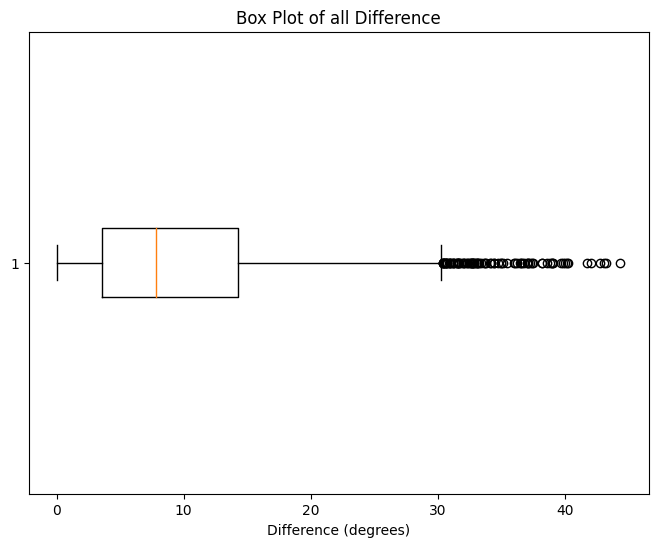

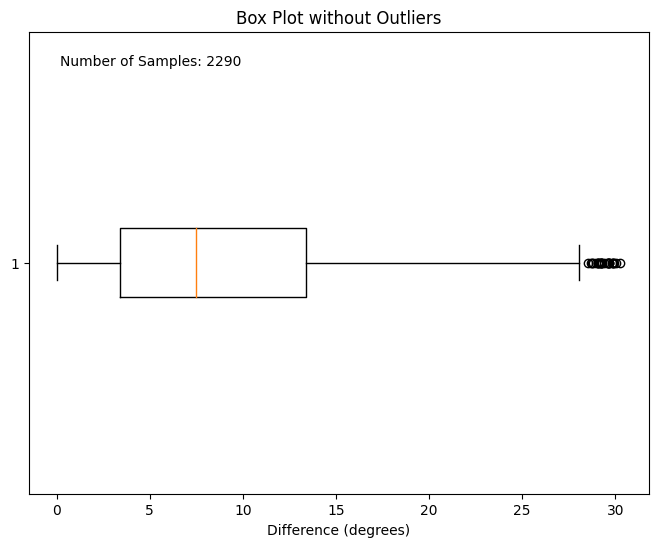

2281
38


In [6]:
#### remove autonomus driving condition , remove outliers and remove targets over 50 degrees because the pointing sensor ######
#### is saturated ########

import matplotlib.pyplot as plt
average_values = average_values[average_values['cond'] != 5.0]
pointing1_nan  = average_values
pointing1_nan = pointing1_nan[((pointing1_nan['target'] >= -50) & (pointing1_nan['target'] <= 50)) ]
                                      

pointing1_nan = pointing1_nan[((pointing1_nan['angle_p'] >= 0) & (pointing1_nan['angle_g'] >= 0)) |
                                      ((pointing1_nan['angle_p'] < 0) & (pointing1_nan['angle_g'] < 0))]

###########  Removing outliers based on diffrences  ####################

difference_data = abs(pointing1_nan['difference'])
# Create a box plot
plt.figure(figsize=(8, 6))
plt.boxplot(difference_data, vert=False)
plt.title('Box Plot of all Difference')
plt.xlabel('Difference (degrees)')

# Calculate quartiles and IQR
Q1 = np.percentile(difference_data, 25)
Q3 = np.percentile(difference_data, 75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify and remove outliers
outliers = (difference_data < lower_bound) | (difference_data > upper_bound)
cleaned_data = pointing1_nan[~outliers]

# Create a box plot without outliers
plt.figure(figsize=(8, 6))
plt.boxplot(abs(cleaned_data['difference']), vert=False)
plt.title('Box Plot without Outliers')
plt.xlabel('Difference (degrees)')

# Add text annotation with the number of samples
num_samples = len(cleaned_data)
plt.text(0.05, 0.95, f'Number of Samples: {num_samples}', transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top')

# Show the plots
plt.show()
pointing1_nan= cleaned_data

#####################################################################################
# Filter rows based on the condition
pointing1_nan = pointing1_nan[(pointing1_nan['side'] == 0.5) | (pointing1_nan['side'] == -0.5)]

pointing1_nan.to_csv('x_dataset_1_filtered.csv', index=False)
print(len(pointing1_nan))
pointing1_nan['participant'].nunique()
print(pointing1_nan['participant'].nunique())


In [7]:
##### combine the 4 th and 5th driving group into one group. ##########
### it is called 6 th group######

data = pointing1_nan
# Grouping the data by 'regularity' and listing unique participants in each group
participants_by_regularity = data.groupby('regularity')['participant'].unique()

# Convert the result into a more readable format
participants_by_regularity_readable = participants_by_regularity.apply(list).to_dict()

participants_by_regularity_readable


data['regularity_updated'] = data['regularity'].apply(lambda x: 6 if x in [4, 5] else x)

# Check if the update is applied correctly by showing unique values of the new column
unique_regularity_updated = data['regularity_updated'].unique()

participants_by_regularity_readable

{1: [15, 17, 28, 29, 38, 50, 63, 68, 73],
 2: [10, 31, 33, 40, 45, 53, 59, 66, 71],
 3: [18, 27, 37, 42, 56, 57, 62],
 4: [9, 11, 14, 23, 24, 30, 41, 46, 67, 72],
 5: [25, 32, 39]}

In [8]:
#### split train and test on participant level ############
#### then split tain into validation and train on data level #########
from sklearn.model_selection import train_test_split

# Initialize empty dataframes for the training and testing sets
train_df = pd.DataFrame()
test_df = pd.DataFrame()

# Group the data by 'regularity_updated' and split participants
for regularity, group_data in data.groupby('regularity_updated'):
    # Get unique participants in the current group
    participants = group_data['participant'].unique()
    
    # Split participants into training and testing groups
    participants_train, participants_test = train_test_split(participants, test_size=0.2, random_state=42)
    
    # Append data of these participants to the respective training/testing dataframe
    train_df = train_df.append(group_data[group_data['participant'].isin(participants_train)])
    test_df = test_df.append(group_data[group_data['participant'].isin(participants_test)])

    
train_df, validation_df = train_test_split(train_df, test_size=0.1, random_state=42)  # random_state ensures reproducibility

# Display the size of the training and testing sets to verify the split
train_df_size = len(train_df)
val_size = len(validation_df)
test_df_size = len(test_df)
total_size = len(data)
train_df_size, val_size, test_df_size, total_size


(1564, 174, 543, 2281)

In [9]:
##### just the list of train and test participants ##############

# Function to get unique participant IDs for training and testing sets per group
def get_participant_ids(df, regularity_col='regularity_updated'):
    group_participants = df.groupby(regularity_col)['participant'].unique().apply(list)
    return group_participants.to_dict()

# Getting unique participant IDs for each group in both training and testing sets
train_participants_ids = get_participant_ids(train_df)
test_participants_ids = get_participant_ids(test_df)

print(train_participants_ids)
print(test_participants_ids)

{1: [28, 63, 29, 38, 73, 15, 50], 2: [59, 10, 53, 33, 40, 45, 71], 3: [42, 57, 37, 56, 62], 6: [14, 46, 32, 11, 23, 25, 30, 72, 39, 24]}
{1: [17, 68], 2: [31, 66], 3: [18, 27], 6: [9, 41, 67]}


In [10]:
### Append the train data, validation data and test data , this will be used by ddpg ############
appended_df = pd.concat([train_df, validation_df, test_df], ignore_index=True)
# Save the appended DataFrame to a CSV file
train_length = len(train_df)
val_length = len(validation_df)
test_length = len(test_df)
filename = f'x_part_data_train{train_length}_val{val_length}_test{test_length}.csv'
appended_df.to_csv(filename, index=False)


############   Run until this cell, further cell for coparing reults ###############


(1564, 3)
(1564, 1)
(174, 3)
(174, 1)
MSE:  0.7970029711723328
RMSE:  0.8927502288839431


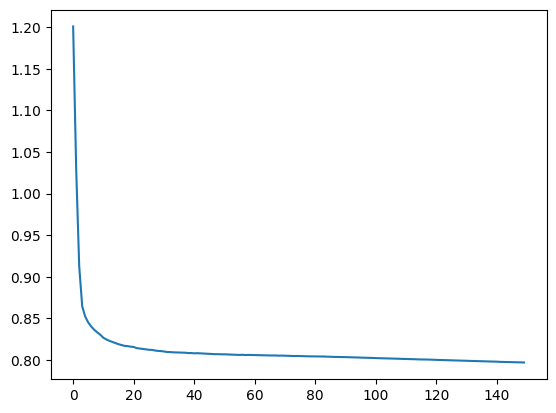

11.94565
12.529513
0.5911602209944752
1.271433836225405


NameError: name 'predictions' is not defined

In [77]:
############### Cells from here are only to implement the rule based model or to test ANN models ###################
############### these can be ignored #################


import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("x_part_data_train1564_val174_test543.csv")

# Split the data into training and testing sets
train_data = df[:1564]
val_data = df [1564 : (1564 + 174)]
test_data = df[(1564 + 174):]


# Extract predictors and target
TargetVariable = ['target']
Predictors = ['angle_p', 'angle_g', 'difference']

X_train = train_data[Predictors].values
y_train = train_data[TargetVariable].values

X_test = val_data[Predictors].values
y_test = val_data[TargetVariable].values

x_t = test_data[Predictors].values
y_t = test_data[TargetVariable].values



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(3, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 150   # number of epochs to run
batch_size = 64  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
acc= abs( test_data['target'] -  a[:, 0] ) / test_data['h_B_w']
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())





(738, 1)
(738, 1)
(83, 1)
(83, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.47305020689964294
RMSE:  0.6877864544316374


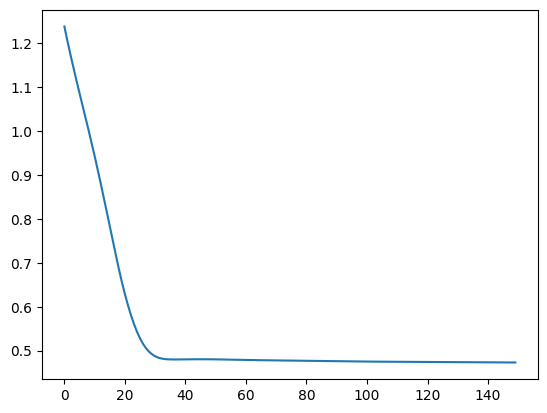

12.149704
12.704627
0.5993589743589743
1.3158970617389898


In [22]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("x_part_data_train1564_val174_test543.csv")

# Split the data into training and testing sets
train_val_data = df[:(1564+174)]
test_data = df[(1564+174):]

# Shuffle the training and validation data
#train_val_data = train_val_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_val_data = train_val_data[train_val_data['difference'] > 0]
test_data = test_data[test_data['difference'] > 0]

from sklearn.model_selection import train_test_split

# Assuming train_val_data is a pandas DataFrame
train_data, val_data = train_test_split(train_val_data, test_size=0.1, random_state=42)
# Further split the training and validation data

# Extract predictors and target
TargetVariable = ['target']
Predictors = ['angle_g']

X_train = train_data[Predictors].values
y_train = train_data[TargetVariable].values

X_test = val_data[Predictors].values
y_test = val_data[TargetVariable].values

x_t = test_data[Predictors].values
y_t = test_data[TargetVariable].values



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
# Define the model
model = nn.Sequential(
    nn.Linear(1, 24),
    nn.ReLU(),
    nn.Linear(24, 24),
    nn.ReLU(),
    nn.Linear(24, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 150   # number of epochs to run
batch_size = 32  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
acc= abs( test_data['target'] -  a[:, 0] ) / test_data['h_B_w']
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())
# Assuming you want to create a new column 'pointing' in a DataFrame





(825, 1)
(825, 1)
(92, 1)
(92, 1)


c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
c:\users\kiran\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


MSE:  0.24410730600357056
RMSE:  0.49407216679708904


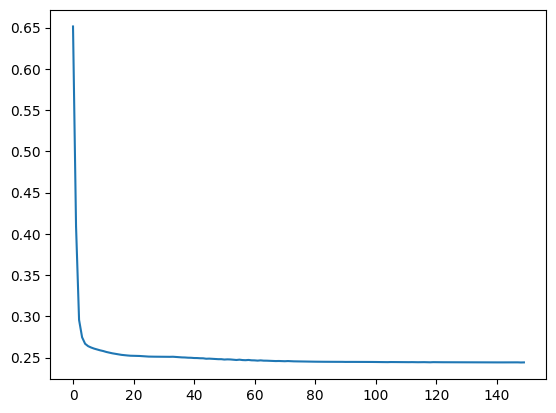

11.472925
12.098134
0.6493506493506493
1.3451490327588904


In [25]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("x_part_data_train1564_val174_test543.csv")

# Split the data into training and testing sets
train_val_data = df[:(1564+174)]
test_data = df[(1564+174):]

# Shuffle the training and validation data
#train_val_data = train_val_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_val_data = train_val_data[train_val_data['difference'] < 0]
test_data = test_data[test_data['difference'] < 0]

from sklearn.model_selection import train_test_split

# Assuming train_val_data is a pandas DataFrame
train_data, val_data = train_test_split(train_val_data, test_size=0.1, random_state=42)
# Further split the training and validation data

# Extract predictors and target
TargetVariable = ['target']
Predictors = ['angle_p']

X_train = train_data[Predictors].values
y_train = train_data[TargetVariable].values

X_test = val_data[Predictors].values
y_test = val_data[TargetVariable].values

x_t = test_data[Predictors].values
y_t = test_data[TargetVariable].values



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
# Define the model
model = nn.Sequential(
    nn.Linear(1, 24),
    nn.ReLU(),
    nn.Linear(24, 24),
    nn.ReLU(),
    nn.Linear(24, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 150   # number of epochs to run
batch_size = 32  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
acc= abs( test_data['target'] -  a[:, 0] ) / test_data['h_B_w']
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())
# Assuming you want to create a new column 'pointing' in a DataFrame





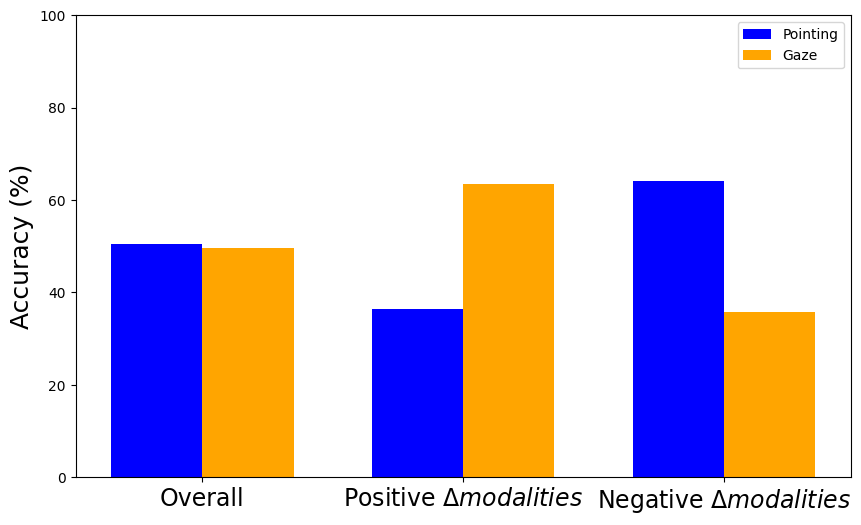

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path_2 = 'x_part_data_train1564_val174_test543.csv'
data_2 = pd.read_csv(file_path_2)
#data_2['difference'] = data_2['pta_average'] - data_2['gza_average']


# Calculate absolute errors for (pta_average - gtv_average) and (gza_average - gtv_average)
data_2['abs_error_pta_gtv'] = abs(data_2['angle_p'] - data_2['target'])
data_2['abs_error_gza_gtv'] = abs(data_2['angle_g'] - data_2['target'])

# Compare the errors
pointing_better = data_2['abs_error_pta_gtv'] < data_2['abs_error_gza_gtv']
gaze_better = data_2['abs_error_gza_gtv'] < data_2['abs_error_pta_gtv']

# Calculate the overall percentage where pointing is better and where gaze is better
percentage_pointing_better = pointing_better.sum() / len(data_2) * 100
percentage_gaze_better = gaze_better.sum() / len(data_2) * 100

# Filter data for positive differences
data_positive = data_2[data_2['difference'] > 0]
# Filter data for negative differences
data_negative = data_2[data_2['difference'] < 0]

# Compare the errors for positive differences
pointing_better_positive = data_positive['abs_error_pta_gtv'] < data_positive['abs_error_gza_gtv']
gaze_better_positive = data_positive['abs_error_gza_gtv'] < data_positive['abs_error_pta_gtv']

# Compare the errors for negative differences
pointing_better_negative = data_negative['abs_error_pta_gtv'] < data_negative['abs_error_gza_gtv']
gaze_better_negative = data_negative['abs_error_gza_gtv'] < data_negative['abs_error_pta_gtv']

# Calculate the percentage where pointing is better and where gaze is better for positive differences
percentage_pointing_better_positive = pointing_better_positive.sum() / len(data_positive) * 100
percentage_gaze_better_positive = gaze_better_positive.sum() / len(data_positive) * 100

# Calculate the percentage where pointing is better and where gaze is better for negative differences
percentage_pointing_better_negative = pointing_better_negative.sum() / len(data_negative) * 100
percentage_gaze_better_negative = gaze_better_negative.sum() / len(data_negative) * 100

# Prepare data for plotting
categories = ['Overall', r'Positive $\Delta{modalities}$ ', r'Negative $\Delta{modalities}$']
pointing_accuracies = [percentage_pointing_better, percentage_pointing_better_positive, percentage_pointing_better_negative]
gaze_accuracies = [percentage_gaze_better, percentage_gaze_better_positive, percentage_gaze_better_negative]

# Create bar plot
x = range(len(categories))
width = 0.35  # Width of the bars

plt.figure(figsize=(10, 6))
plt.bar(x, pointing_accuracies, width, label='Pointing', color='blue')
plt.bar([p + width for p in x], gaze_accuracies, width, label='Gaze', color='orange')

# Add labels and title
#plt.xlabel('Conditions', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=18)
#plt.title('Comparison of Pointing and Gaze Accuracies', fontsize=16)
plt.xticks([p + width / 2 for p in x], categories, fontsize=17)
plt.ylim(0, 100)

# Add a legend
plt.legend()

# Display the plot
plt.show()


(1564, 3)
(1564, 1)
(174, 3)
(174, 1)
MSE:  0.22992171347141266
RMSE:  0.4795015260365838


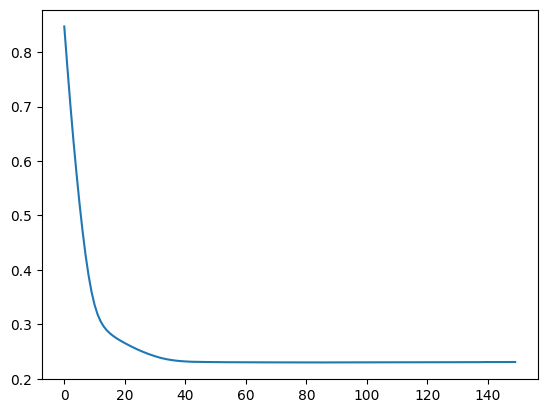

12.587418
12.671518
0.5911602209944752
1.2936546186047329


In [19]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
# Load the dataset from the uploaded file
df = pd.read_csv("x_part_data_train1564_val174_test543.csv")

# Split the data into training and testing sets
train_data = df[:1564]
val_data = df [1564 : (1564 + 174)]
test_data = df[(1564 + 174):]


# Extract predictors and target
TargetVariable = ['target']
Predictors = ['angle_p', 'angle_g', 'difference']

X_train = train_data[Predictors].values
y_train = train_data[TargetVariable].values

X_test = val_data[Predictors].values
y_test = val_data[TargetVariable].values

x_t = test_data[Predictors].values
y_t = test_data[TargetVariable].values



from sklearn.preprocessing import StandardScaler


### Sandardization of data ###
from sklearn.preprocessing import StandardScaler
PredictorScaler=StandardScaler()
TargetVarScaler=StandardScaler()
 
# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X_train)
TargetVarScalerFit=TargetVarScaler.fit(y_train)
 
# Generating the standardized values of X and y
X_train=PredictorScalerFit.transform(X_train)
y_train=TargetVarScalerFit.transform(y_train)
X_test=PredictorScalerFit.transform(X_test)
y_test=TargetVarScalerFit.transform(y_test)

x_t=PredictorScalerFit.transform(x_t)
y_t=TargetVarScalerFit.transform(y_t)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)




# Read data
#data = fetch_california_housing()
#X, y = data.data, data.target

# train-test split for model evaluation
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
x_t = torch.tensor(x_t, dtype=torch.float32)
y_t = torch.tensor(y_t, dtype=torch.float32)

# Define the model
model = nn.Sequential(
    nn.Linear(3, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)

# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 150   # number of epochs to run
batch_size = 256  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: " , best_mse)
print("RMSE: " , np.sqrt(best_mse))
plt.plot(history)
plt.show()

a = TargetVarScalerFit.inverse_transform(model(X_test).detach().numpy())
from sklearn.metrics import mean_squared_error
rms = mean_squared_error(y_test.numpy(), a, squared=False)
print(rms)
a = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())
rms = mean_squared_error(y_t.numpy(), a, squared=False)
print(rms)
a_flat = a[:, 0]
acc= abs( test_data['target'] -  a[:, 0] ) / test_data['h_B_w']
print(( acc < 1).sum() / len(acc)  )

print( acc .sum() / len(acc)  )
pointing_model =model
scaled_predictions = TargetVarScalerFit.inverse_transform(model(X_train).detach().numpy())



In [30]:
# Assuming 'participant_id' column in test_data to identify participants
# If you don't have it, make sure to include one for each participant.
participant_ids = test_data['participant'].values  # Replace with correct column name

# Recalculate predictions for the test set
scaled_predictions_test = TargetVarScalerFit.inverse_transform(model(x_t).detach().numpy())

# Compute the absolute percentage error per participant
errors = abs(test_data['target'] - scaled_predictions_test[:, 0]) / test_data['h_B_w']


# Create a DataFrame to organize the errors by participant
results_df = pd.DataFrame({
    'participant_id': participant_ids,
    'target': test_data['target'].values,
    'predictions': scaled_predictions_test[:, 0],
    'errors': errors
})


threshold = 1  

# Calculate accuracy per participant
participant_mrde = results_df.groupby('participant_id').apply(lambda df: (df['errors']).mean())

print('Standard error: ', np.std(participant_mrde)/ (len(participant_mrde)**0.5))

Standard error:  0.24214828208815112
